# Shard-link diagnostics (Step-2 graph)

Stage-1 **semantic shards are already very pure** on labeled email GT; the bottleneck for campaign recovery is how shards connect in the **Step-2 shard graph**.

This notebook treats that graph as the main object: **which shard links exist**, what **evidence channels** they carry, and how **same-campaign** vs **cross-campaign** links differ (GT is used only to label edges for analysis, plus shard purity and oracle ceilings).

**Oracle / ceiling metrics** remain useful: they show the **maximum** homogeneity / completeness / V-measure achievable if merges followed GT, with (**A**) no graph constraint vs (**B**) only along existing Step-2 edges.

The open design question for **unsupervised** shard-edge bucketing is which links are **true bridges** vs **false bridges**. **HS-LI** (high semantic similarity, low infrastructure overlap) is the main **false-bridge** regime to inspect: semantic pull without corroborating infra.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_here = Path.cwd().resolve()
PROJECT_ROOT = _here if (_here / "pipeline_config.json").is_file() else _here.parent
assert (PROJECT_ROOT / "pipeline_config.json").is_file(), PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

STEP1_ASSIGNMENTS = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step1" / "semantic_shard_step1_assignments.csv"
STEP2_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step2_graph"
GT_JSON = PROJECT_ROOT / "data" / "groundtruth" / "ground_truth.json"

OUT_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_oracle_headroom"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_DOMINANT_FRAC_FOR_EDGE_LABEL = 0.7
ORACLE_PURITY_THRESHOLD = 1.0

COLOR_SAME = "#1f77b4"
COLOR_CROSS = "#ff7f0e"
COLOR_AMBIG = "#7f7f7f"
COLOR_HSLI = "#9467bd"
COLOR_NON_HSLI = "#bcbd22"


In [2]:
from IPython.display import Markdown, display

from analysis.utils.raw_gnn_notebook import load_ground_truth_structures
from analysis.utils.semantic_shard_oracle_headroom_helpers import (
    ARTIFACT_OVERLAP_DIAG_SPECS,
    CROSS_EDGE_CHANNEL_INSPECTION_SPECS,
    plot_label_short,
    artifact_filtering_candidates,
    build_artifact_shard_frequency_maps,
    build_edge_analysis_dataframe,
    build_shard_gt_summary,
    build_shard_member_ids_index,
    cross_edge_channel_presence_summary,
    evidence_binary_column_specs,
    expand_labeled_edges_to_artifact_incidence,
    find_body_subject_semantic_columns,
    label_candidate_edges_taxonomy,
    load_step1_assignments,
    metrics_pure_shards_as_clusters,
    oracle_metrics_from_shard_map,
    oracle_scenarios_comparison_df,
    sample_cross_edges_for_channel_inspection,
    shard_purity_global_summary,
    summarize_artifact_link_induction,
    top_mixed_shards,
    write_oracle_headroom_summary_md,
    _shard_to_oracle_community_ids,
)
from analysis.utils.semantic_shard_step3_helpers import load_step2_artifacts

gt_label_map, _eid_row, _campaign_to_members = load_ground_truth_structures(GT_JSON)
assignments_df = load_step1_assignments(STEP1_ASSIGNMENTS)
nodes_df, edges_df, _candidates_df = load_step2_artifacts(STEP2_DIR)

print("labeled GT emails:", len(gt_label_map))
print("assignments rows:", len(assignments_df))
print("step2 edges:", len(edges_df))


labeled GT emails: 1472
assignments rows: 4437
step2 edges: 1720


## 1. Compact shard purity + oracle ceilings

**Shard purity:** external clustering metrics when each shard is one cluster (labeled emails only).

**Oracle A / B:** perfect same-campaign merging among shards that pass the purity threshold — **A** ignores the graph; **B** only merges along Step-2 edges. The gap is the **connectivity ceiling** imposed by the current candidate graph.

Below: key numbers only (detail CSVs still written to `OUT_DIR`), plus a small V-measure comparison chart.


### Clustering metrics (labeled emails)

,n_eval,homogeneity,completeness,v_measure,n_shards_with_labeled
0,1472,0.9978,0.6356,0.7766,348


### Shard-level purity (compact)

,n_shards_with_labeled,n_pure_shards,n_mixed_shards,frac_labeled_in_pure_shards,weighted_avg_dominant_fraction
0,348,343,5,0.9857,0.9966


Mixed labeled shards (see CSV): 5


...

### Oracle A vs B (graph constraint)

,n_eval,homogeneity,completeness,v_measure,coverage_gt,n_communities,n_shards,n_shards_merged_proxy
0,1472.0,0.9978,0.984,0.9909,1.0,1367.0,1673.0,306.0


,n_eval,homogeneity,completeness,v_measure,coverage_gt,n_communities,n_shards,n_shards_merged_proxy
0,1472.0,0.9978,0.8547,0.9207,1.0,1455.0,1673.0,218.0


**B − A**

,completeness,v_measure,n_communities,n_shards_merged_proxy
0,-0.1294,-0.0702,88.0,-88.0


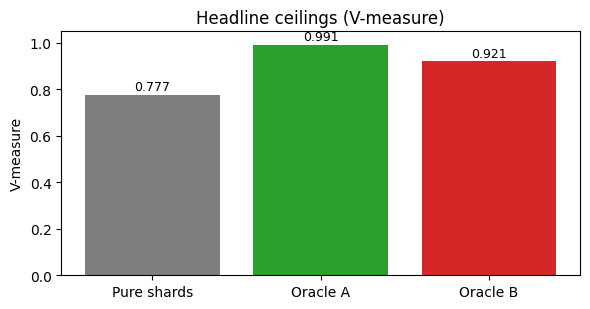

In [3]:
# Shard ↔ GT summary + oracle maps
shard_summary = build_shard_gt_summary(assignments_df, gt_label_map)
shard_summary.to_csv(OUT_DIR / "shard_purity_per_shard.csv", index=False)

pure_metrics = metrics_pure_shards_as_clusters(assignments_df, gt_label_map)
purity_global = shard_purity_global_summary(shard_summary, gt_label_map)
pd.DataFrame([{**pure_metrics, **purity_global}]).to_csv(
    OUT_DIR / "shard_purity_global_summary.csv", index=False
)

mixed_top = top_mixed_shards(shard_summary, n=20)
mixed_top.to_csv(OUT_DIR / "shard_purity_top_mixed_shards.csv", index=False)

map_a = _shard_to_oracle_community_ids(
    shard_summary, purity_threshold=ORACLE_PURITY_THRESHOLD, graph_edges=None
)
map_b = _shard_to_oracle_community_ids(
    shard_summary, purity_threshold=ORACLE_PURITY_THRESHOLD, graph_edges=edges_df
)
oracle_a = oracle_metrics_from_shard_map(assignments_df, map_a, gt_label_map)
oracle_b = oracle_metrics_from_shard_map(assignments_df, map_b, gt_label_map)
pd.DataFrame([oracle_a]).to_csv(OUT_DIR / "oracle_A_metrics.csv", index=False)
pd.DataFrame([oracle_b]).to_csv(OUT_DIR / "oracle_B_metrics.csv", index=False)

display(Markdown("### Clustering metrics (labeled emails)"))
display(pd.DataFrame([pure_metrics]).round(4))
display(Markdown("### Shard-level purity (compact)"))
display(pd.DataFrame([purity_global]).round(4))
print(f"Mixed labeled shards (see CSV): {int(purity_global.get('n_mixed_shards', 0))}")
display(mixed_top.head(5))

display(Markdown("### Oracle A vs B (graph constraint)"))
display(pd.DataFrame([oracle_a]).round(4))
display(pd.DataFrame([oracle_b]).round(4))
_delta_keys = ("completeness", "v_measure", "n_communities", "n_shards_merged_proxy")
_delta = {
    k: float(oracle_b[k]) - float(oracle_a[k])
    for k in _delta_keys
    if k in oracle_a and k in oracle_b and pd.notna(oracle_a[k]) and pd.notna(oracle_b[k])
}
display(Markdown("**B − A**"))
display(pd.DataFrame([_delta]).round(4))

cmp = oracle_scenarios_comparison_df(
    pure_shard_metrics=pure_metrics, oracle_a=oracle_a, oracle_b=oracle_b
)
cmp.to_csv(OUT_DIR / "oracle_ceiling_scenarios.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 3.2))
xs = ["Pure shards", "Oracle A", "Oracle B"]
ys = [pure_metrics["v_measure"], oracle_a["v_measure"], oracle_b["v_measure"]]
bars = ax.bar(xs, ys, color=[COLOR_AMBIG, "#2ca02c", "#d62728"])
ax.set_ylabel("V-measure")
ax.set_title("Headline ceilings (V-measure)")
ax.set_ylim(0, 1.05)
for b, v in zip(bars, ys):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


## 2. Central labeled shard-link table (`edge_analysis_df`)

Each row is one undirected Step-2 edge. **Ground truth** supplies `link_label` (**same** / **cross** / **ambiguous**) via shard dominant campaigns (same rules as before).

**`is_hsli`:** high `centroid_cosine` (≥ median) **and** low `infra_score` (≤ median) among edges with finite scores — the high-semantic, low-infra quadrant.

Boolean **`has_*`** columns mark **non-zero** shared-count infra channels, temporal overlap (or strong temporal score), optional V2 local-rank columns if you merge them in later, and separate body/subject semantics **only if** those columns exist on the edge table (standard Step-2 export is aggregate cosine only).


In [4]:
edges_tax = label_candidate_edges_taxonomy(
    edges_df,
    shard_summary,
    min_dominant_fraction=MIN_DOMINANT_FRAC_FOR_EDGE_LABEL,
)
edges_tax.to_csv(OUT_DIR / "candidate_edges_labeled_taxonomy.csv", index=False)

edge_analysis_df = build_edge_analysis_dataframe(edges_df, edges_tax)
edge_analysis_df.to_csv(OUT_DIR / "edge_analysis_df.csv", index=False)

print("edge_analysis_df:", edge_analysis_df.shape)
print("Columns (sample):", list(edge_analysis_df.columns[:18]), "...")
display(edge_analysis_df[["shard_a", "shard_b", "link_label", "is_hsli", "n_evidence_channels"]].head(3))


edge_analysis_df: (1720, 53)
Columns (sample): ['shard_a', 'shard_b', 'centroid_cosine', 'shared_url_count', 'url_jaccard', 'shared_url_idf_sum', 'shared_url_n_cutoff_filtered', 'infra_contrib_url_pre_cap', 'infra_contrib_url', 'shared_sender_email_domain_count', 'sender_email_domain_jaccard', 'shared_sender_email_domain_idf_sum', 'shared_sender_email_domain_n_cutoff_filtered', 'infra_contrib_sender_email_domain_pre_cap', 'infra_contrib_sender_email_domain', 'shared_domain_count', 'domain_jaccard', 'shared_domain_idf_sum'] ...


,shard_a,shard_b,link_label,is_hsli,n_evidence_channels
0,shard_215,shard_204,same,False,3
1,shard_215,shard_217,same,False,3
2,shard_215,shard_203,same,False,3


## 3. Labeled-link composition

Quick counts of **same** / **cross** / **ambiguous**, and how **HS-LI** splits those buckets.


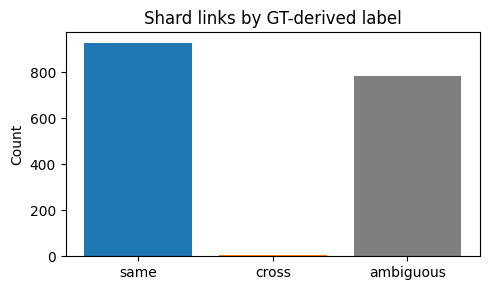

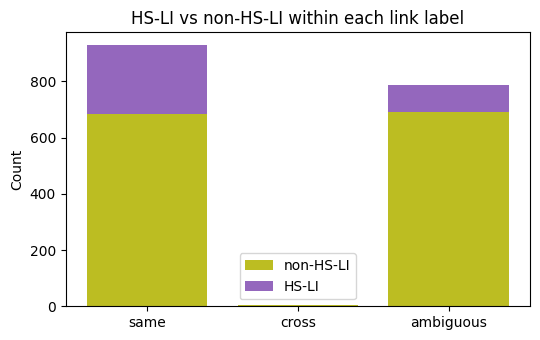

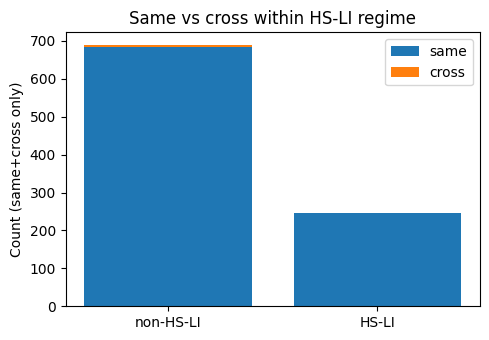

In [5]:
def _countplot_link_labels(df: pd.DataFrame) -> None:
    vc = df["link_label"].value_counts().reindex(["same", "cross", "ambiguous"]).fillna(0).astype(int)
    fig, ax = plt.subplots(figsize=(5, 3))
    colors = [COLOR_SAME, COLOR_CROSS, COLOR_AMBIG]
    ax.bar(vc.index.astype(str), vc.values, color=colors)
    ax.set_ylabel("Count")
    ax.set_title("Shard links by GT-derived label")
    plt.tight_layout()
    plt.show()


def _stacked_taxonomy_hsli(df: pd.DataFrame, *, inside: str) -> None:
    if inside == "label":
        idx = ["same", "cross", "ambiguous"]
        sub = df[df["link_label"].isin(["same", "cross", "ambiguous"])]
        pivot = (
            sub.groupby(["link_label", "is_hsli"], dropna=False)
            .size()
            .unstack(fill_value=0)
            .reindex(idx)
        )
        pivot.columns = [bool(c) for c in pivot.columns]
        fig, ax = plt.subplots(figsize=(5.5, 3.5))
        bottom = np.zeros(len(pivot))
        for flag, lab, col in [
            (False, "non-HS-LI", COLOR_NON_HSLI),
            (True, "HS-LI", COLOR_HSLI),
        ]:
            if flag in pivot.columns:
                vals = pivot[flag].values.astype(float)
            else:
                vals = np.zeros(len(pivot))
            ax.bar(pivot.index.astype(str), vals, bottom=bottom, label=lab, color=col)
            bottom = bottom + vals
        ax.set_ylabel("Count")
        ax.set_title("HS-LI vs non-HS-LI within each link label")
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        sub = df[df["link_label"].isin(["same", "cross"])]
        pivot = (
            sub.groupby(["is_hsli", "link_label"], dropna=False)
            .size()
            .unstack(fill_value=0)
        )
        pivot = pivot.reindex([False, True])
        pivot.columns = [str(c) for c in pivot.columns]
        fig, ax = plt.subplots(figsize=(5, 3.5))
        bottom = np.zeros(len(pivot))
        for col_name, color in [("same", COLOR_SAME), ("cross", COLOR_CROSS)]:
            if col_name in pivot.columns:
                vals = pivot[col_name].values.astype(float)
            else:
                vals = np.zeros(len(pivot))
            ax.bar(["non-HS-LI", "HS-LI"], vals, bottom=bottom, label=col_name, color=color)
            bottom = bottom + vals
        ax.set_ylabel("Count (same+cross only)")
        ax.set_title("Same vs cross within HS-LI regime")
        ax.legend()
        plt.tight_layout()
        plt.show()


_countplot_link_labels(edge_analysis_df)
_stacked_taxonomy_hsli(edge_analysis_df, inside="label")
_stacked_taxonomy_hsli(edge_analysis_df, inside="hsli")


## 4. Shard-link evidence anatomy

**Prevalence is not trustworthiness** — a channel can be common on cross edges too — but this shows **what shard links are made of**. **HS-LI** matters because it is the main regime where semantic similarity pulls without infra corroboration.

Grouped bars: fraction of edges (within **same** vs **cross**) that activate each boolean channel. Ambiguous edges are excluded from these fractions.


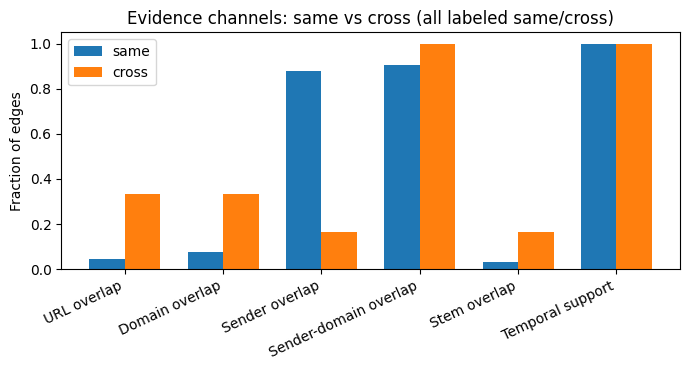

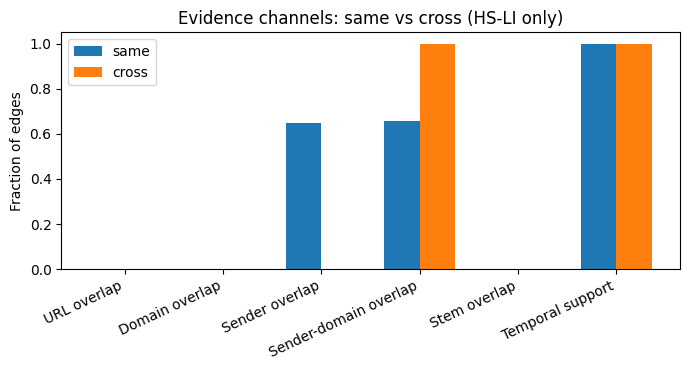

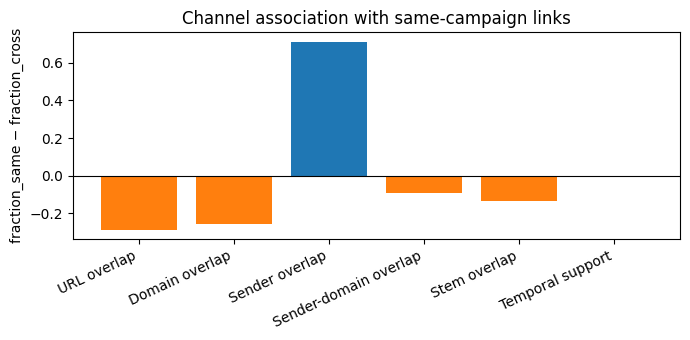

In [6]:
specs = evidence_binary_column_specs(edge_analysis_df)
labeled = edge_analysis_df[edge_analysis_df["link_label"].isin(["same", "cross"])].copy()

if not specs:
    display(Markdown("_No boolean evidence columns found._"))
else:
    def frac_active(sub: pd.DataFrame, col: str) -> float:
        if sub.empty or col not in sub.columns:
            return float("nan")
        return float(sub[col].astype(bool).mean())

    plot_labels = [s[0] for s in specs]
    plot_cols = [s[1] for s in specs]

    def plot_grouped(sub: pd.DataFrame, title: str) -> None:
        fs = [frac_active(sub[sub["link_label"] == "same"], c) for c in plot_cols]
        fc = [frac_active(sub[sub["link_label"] == "cross"], c) for c in plot_cols]
        x = np.arange(len(plot_labels))
        w = 0.36
        fig, ax = plt.subplots(figsize=(max(7, len(plot_labels) * 0.9), 3.8))
        ax.bar(x - w / 2, fs, width=w, label="same", color=COLOR_SAME)
        ax.bar(x + w / 2, fc, width=w, label="cross", color=COLOR_CROSS)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_labels, rotation=25, ha="right")
        ax.set_ylabel("Fraction of edges")
        ax.set_ylim(0, 1.05)
        ax.legend()
        ax.set_title(title)
        plt.tight_layout()
        plt.show()

    plot_grouped(labeled, "Evidence channels: same vs cross (all labeled same/cross)")
    hs = labeled[labeled["is_hsli"]]
    if len(hs) > 0:
        plot_grouped(hs, "Evidence channels: same vs cross (HS-LI only)")
    diff_vals = [
        frac_active(labeled[labeled["link_label"] == "same"], c)
        - frac_active(labeled[labeled["link_label"] == "cross"], c)
        for c in plot_cols
    ]
    fig, ax = plt.subplots(figsize=(max(7, len(plot_labels) * 0.9), 3.5))
    colors = [COLOR_SAME if d >= 0 else COLOR_CROSS for d in diff_vals]
    ax.bar(np.arange(len(plot_labels)), diff_vals, color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(np.arange(len(plot_labels)))
    ax.set_xticklabels(plot_labels, rotation=25, ha="right")
    ax.set_ylabel("fraction_same − fraction_cross")
    ax.set_title("Channel association with same-campaign links")
    plt.tight_layout()
    plt.show()


## 5. Number of active evidence channels per link

Do same-campaign links carry **more corroborating channels** than cross-campaign links? Count = sum of the boolean channels used for `n_evidence_channels` in §2.


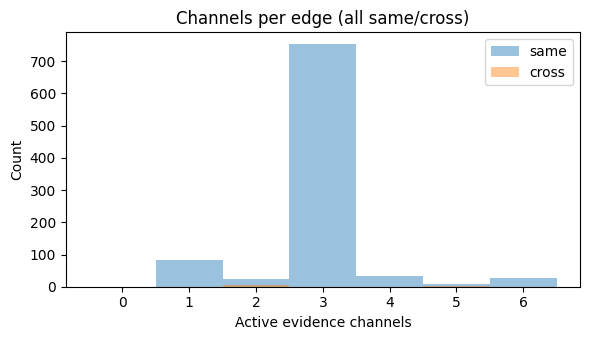

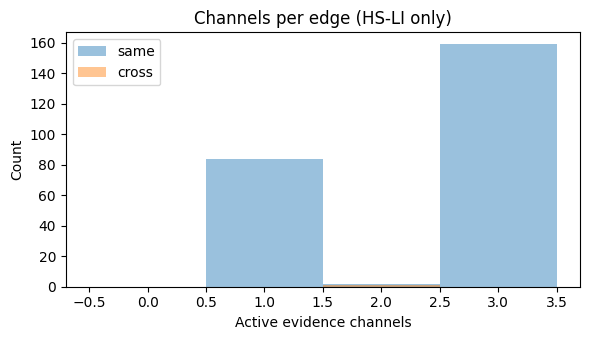

,group,mean_n_channels,n
0,same (all),2.9386,928
1,same HS-LI,2.3061,245
2,same non-HS-LI,3.1654,683
3,cross (all),3.0000,6
4,cross HS-LI,2.0000,1
5,cross non-HS-LI,3.2000,5


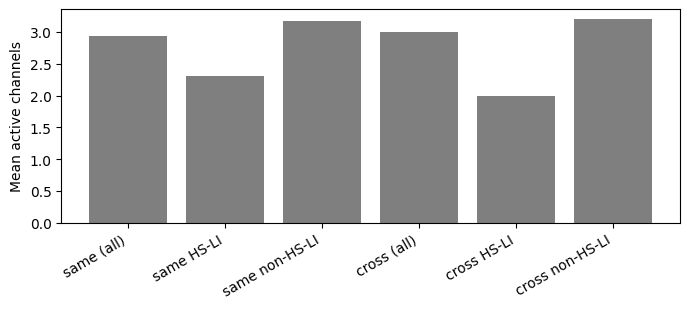

In [7]:
def plot_channel_count_hists(df: pd.DataFrame, title_suffix: str) -> None:
    sub = df[df["link_label"].isin(["same", "cross"])].copy()
    if sub.empty:
        display(Markdown("_No same/cross rows._"))
        return
    fig, ax = plt.subplots(figsize=(6, 3.5))
    bins = np.arange(-0.5, sub["n_evidence_channels"].max() + 1.5, 1)
    for lab, color in [("same", COLOR_SAME), ("cross", COLOR_CROSS)]:
        x = sub.loc[sub["link_label"] == lab, "n_evidence_channels"]
        ax.hist(x, bins=bins, alpha=0.45, label=lab, color=color, density=False)
    ax.set_xlabel("Active evidence channels")
    ax.set_ylabel("Count")
    ax.set_title(f"Channels per edge ({title_suffix})")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_channel_count_hists(edge_analysis_df, "all same/cross")
plot_channel_count_hists(edge_analysis_df[edge_analysis_df["is_hsli"]], "HS-LI only")

rows = []
for lab in ["same", "cross"]:
    sub_all = edge_analysis_df[edge_analysis_df["link_label"] == lab]
    rows.append(
        {
            "group": f"{lab} (all)",
            "mean_n_channels": float(sub_all["n_evidence_channels"].mean()) if len(sub_all) else float("nan"),
            "n": int(len(sub_all)),
        }
    )
    for hsli in (True, False):
        m = (edge_analysis_df["link_label"] == lab) & (edge_analysis_df["is_hsli"] == hsli)
        sub = edge_analysis_df[m]
        rows.append(
            {
                "group": f"{lab} {'HS-LI' if hsli else 'non-HS-LI'}",
                "mean_n_channels": float(sub["n_evidence_channels"].mean()) if len(sub) else float("nan"),
                "n": int(len(sub)),
            }
        )
mean_df = pd.DataFrame(rows)
display(mean_df.round(4))
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(mean_df["group"], mean_df["mean_n_channels"], color=COLOR_AMBIG)
ax.set_ylabel("Mean active channels")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 6. Subject vs body semantic support

**Hypothesis:** subject-level similarity may be a **noisier** false-bridge signal than body-level similarity.

This section runs **only if** the edge table contains distinct body and subject semantic columns (see helper `find_body_subject_semantic_columns`). The default Step-2 `semantic_shard_step2_edges_weighted.csv` has a **single** `centroid_cosine` only — in that case we skip plots and note that you can re-run after enriching edges.


In [8]:
cat = edge_analysis_df["semantic_channel_category"]
if (cat == "unavailable").all():
    display(
        Markdown(
            "**Skipped:** no `body_*` / `subject_*` semantic columns on edges. "
            "Aggregate `centroid_cosine` is still in `edge_analysis_df` for §7."
        )
    )
else:
    sub = edge_analysis_df[edge_analysis_df["link_label"].isin(["same", "cross"])].copy()
    cats = ["body_only", "subject_only", "both", "neither"]
    ct = (
        sub.groupby(["semantic_channel_category", "link_label"])
        .size()
        .unstack(fill_value=0)
        .reindex(cats)
    )

    fig, ax = plt.subplots(figsize=(7, 3.8))
    x = np.arange(len(cats))
    w = 0.36
    ax.bar(x - w / 2, ct.get("same", pd.Series(0, index=ct.index)), width=w, label="same", color=COLOR_SAME)
    ax.bar(x + w / 2, ct.get("cross", pd.Series(0, index=ct.index)), width=w, label="cross", color=COLOR_CROSS)
    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    ax.set_ylabel("Count")
    ax.set_title("Semantic support category × link label")
    ax.legend()
    plt.tight_layout()
    plt.show()

    same_rate = []
    for c in cats:
        s = sub[sub["semantic_channel_category"] == c]
        same_rate.append(float((s["link_label"] == "same").mean()) if len(s) else float("nan"))
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.bar(cats, same_rate, color=COLOR_AMBIG)
    ax.set_ylabel("P(same | category)")
    ax.set_ylim(0, 1.05)
    ax.set_title("Same-rate by semantic support category")
    plt.tight_layout()
    plt.show()

    hs = sub[sub["is_hsli"]]
    sr_hs = []
    for c in cats:
        s = hs[hs["semantic_channel_category"] == c]
        sr_hs.append(float((s["link_label"] == "same").mean()) if len(s) else float("nan"))
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.bar(cats, sr_hs, color=COLOR_HSLI)
    ax.set_ylabel("P(same | category)")
    ax.set_title("Same-rate by category (HS-LI only)")
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

    body_col, subj_col = find_body_subject_semantic_columns(edge_analysis_df)
    if body_col and subj_col:
        fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
        for ax, col, title in zip(
            axes,
            (body_col, subj_col),
            ("Body semantic score", "Subject semantic score"),
        ):
            for lab, color in [("same", COLOR_SAME), ("cross", COLOR_CROSS)]:
                x = pd.to_numeric(sub.loc[sub["link_label"] == lab, col], errors="coerce").dropna()
                ax.hist(x, bins=40, alpha=0.45, label=lab, color=color, density=True)
            ax.set_title(title)
            ax.legend()
        plt.tight_layout()
        plt.show()


**Skipped:** no `body_*` / `subject_*` semantic columns on edges. Aggregate `centroid_cosine` is still in `edge_analysis_df` for §7.

## 7. Optional feature distributions (same vs cross)

**Same vs cross** on a few scalars already on the edge table. **HS-LI** overlay where helpful. Skips any missing column.


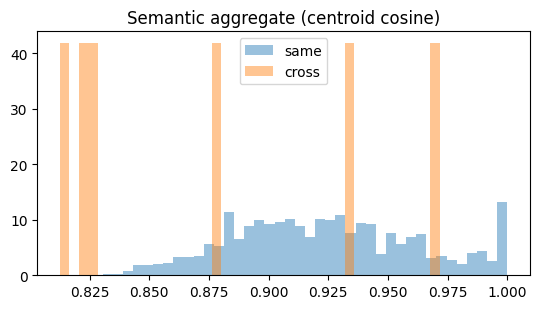

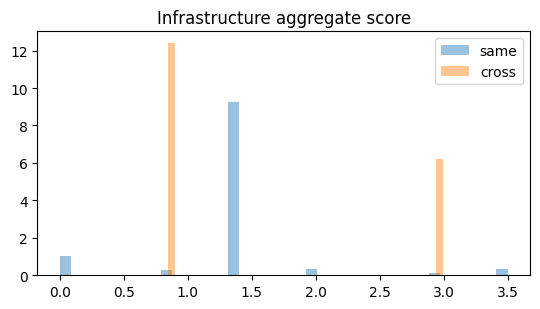

**HS-LI subset:** same vs cross on semantic / infra

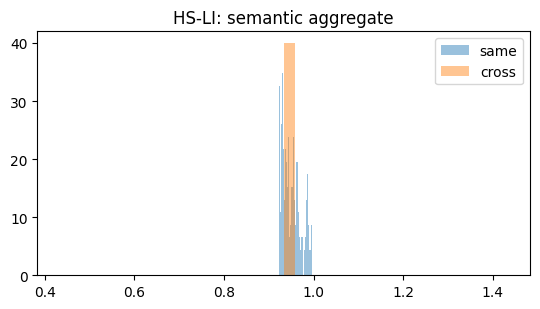

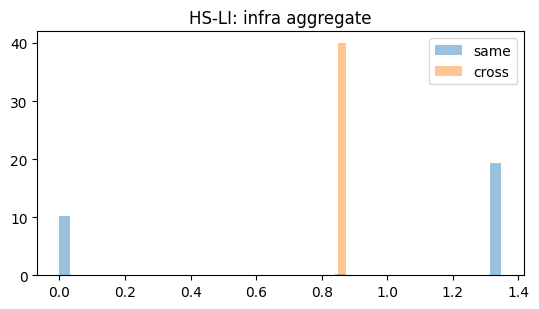

In [9]:
def _hist_same_cross(series_same, series_cross, title: str) -> None:
    fig, ax = plt.subplots(figsize=(5.5, 3.2))
    if len(series_same) or len(series_cross):
        bins = 40
        ax.hist(series_same.dropna(), bins=bins, alpha=0.45, label="same", color=COLOR_SAME, density=True)
        ax.hist(series_cross.dropna(), bins=bins, alpha=0.45, label="cross", color=COLOR_CROSS, density=True)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


sub = edge_analysis_df[edge_analysis_df["link_label"].isin(["same", "cross"])].copy()
same_m = sub["link_label"] == "same"
cross_m = sub["link_label"] == "cross"

for col, title in [
    ("semantic_aggregate", "Semantic aggregate (centroid cosine)"),
    ("infra_aggregate", "Infrastructure aggregate score"),
    ("v2_local_embeddedness_rank", "Local embeddedness rank (if present)"),
    ("v2_infra_dominance", "Infra dominance / hub signal (if present)"),
]:
    if col not in sub.columns:
        continue
    v = pd.to_numeric(sub[col], errors="coerce")
    _hist_same_cross(v[same_m], v[cross_m], title)

# HS-LI: semantic + infra only (always expected on Step-2)
hs = sub[sub["is_hsli"]]
if len(hs) > 5:
    display(Markdown("**HS-LI subset:** same vs cross on semantic / infra"))
    for col, title in [("semantic_aggregate", "HS-LI: semantic aggregate"), ("infra_aggregate", "HS-LI: infra aggregate")]:
        if col in hs.columns:
            v = pd.to_numeric(hs[col], errors="coerce")
            _hist_same_cross(v[hs["link_label"] == "same"], v[hs["link_label"] == "cross"], title)


## 8. Inspectable cross-edge examples by evidence channel

For **cross-campaign** shard links only (`link_label == "cross"`), sample edges where a given infra channel fires (`has_*` flag). Ordering prioritizes **HS-LI**, then **higher semantic aggregate**, then **stronger overlap** (shared count / IDF sum when present).

**Shared values** (e.g. actual overlapping URLs) are computed as the **intersection** of the two shards’ sets from `semantic_shard_step2_nodes.csv` when the corresponding `*_set` column exists. If that column is missing, the table still shows shard IDs, GT summaries, and overlap counts from the edge row.

**Email IDs:** Every **`external_id`** in each endpoint shard is shown: the table columns use one id per line, Jupyter wide cells are enabled via `display.max_colwidth`, and the text block below each example prints the **full** src/dst lists (no `+N more`). To cap lists again, pass a positive `max_member_ids_preview` into `sample_cross_edges_for_channel_inspection`.

Use this for manual review of **GT noise**, **generic features** (especially stems), and whether some channels should be **gated or downweighted** in unsupervised bucket design.

Cross-labeled edges: 6


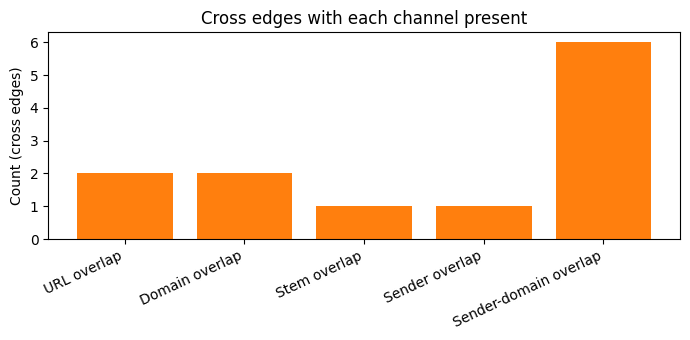

,channel,n_cross_with_channel,frac_of_cross
0,URL overlap,2,0.3333
1,Domain overlap,2,0.3333
2,Stem overlap,1,0.1667
3,Sender overlap,1,0.1667
4,Sender-domain overlap,6,1.0000


### URL overlap

,src_shard,dst_shard,src_member_ids_preview,dst_member_ids_preview,src_dominant_campaign,dst_dominant_campaign,src_dominant_fraction,dst_dominant_fraction,src_size,dst_size,is_hsli,semantic_aggregate,infra_aggregate,shared_url_count,shared_url_idf_sum,shared_values_preview
0,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwR_QAAAA==,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwSGgAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwR_QAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwSGgAAAA==,15.0,166.0,1.0,1.0,1,1,False,0.9718,2.9493,2,14.6487,www.imoney727.com/*; www.imoney727.com/*]
1,shard_107,shard_369,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnoZDlAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3MwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3cgAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru8nQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP51QAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5rAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5rwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5sQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5sgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5uwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5wQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5xgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5yQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5zQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6EAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6EQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6GgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6LgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADtczP0AAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAA

noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwR_QAAAA== ↔ noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwSGgAAAA== | campaigns 15.0 vs 166.0 | HS-LI=False | sem=0.972 infra=2.949 | shared: www.imoney727.com/*; www.imoney727.com/*]
  src external_ids (full):
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwR_QAAAA==
  dst external_ids (full):
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwSGgAAAA==
shard_107 ↔ shard_369 | campaigns 41.0 vs 206.0 | HS-LI=False | sem=0.825 infra=2.997 | shared: www.landkreis-osnabrueck.de/; www.landkreis-osnabrueck.de/]; www.landkreis-osnabrueck.de/facebook; w

### Domain overlap

...

,src_shard,dst_shard,src_member_ids_preview,dst_member_ids_preview,src_dominant_campaign,dst_dominant_campaign,src_dominant_fraction,dst_dominant_fraction,src_size,dst_size,is_hsli,semantic_aggregate,infra_aggregate,shared_sender_count,shared_sender_idf_sum,shared_values_preview
0,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwR_QAAAA==,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwSGgAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwR_QAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwSGgAAAA==,15.0,166.0,1.0,1.0,1,1,False,0.9718,2.9493,1,7.3244,info@imoney727.com


noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwR_QAAAA== ↔ noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwSGgAAAA== | campaigns 15.0 vs 166.0 | HS-LI=False | sem=0.972 infra=2.949 | shared: info@imoney727.com
  src external_ids (full):
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwR_QAAAA==
  dst external_ids (full):
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwSGgAAAA==



### Sender-domain overlap

,src_shard,dst_shard,src_member_ids_preview,dst_member_ids_preview,src_dominant_campaign,dst_dominant_campaign,src_dominant_fraction,dst_dominant_fraction,src_size,dst_size,is_hsli,semantic_aggregate,infra_aggregate,shared_sender_email_domain_count,shared_sender_email_domain_idf_sum,shared_values_preview
0,shard_471,shard_446,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADkrJAXQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADkrJAXgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADkrJAcgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADkrJAfAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADkrJAkQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADlG_S-gAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADmbqLfwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADmbqLhAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADmbqLlQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADmbqLrAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADmbqLswAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADmbqLugAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADmbqMlAAAAA==,74.0,147.0,1.0,1.0,6,7,True,0.9331,0.8493,1,7.0367,bonjour.taxi
1,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwR_QAAAA==,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwSGgAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwR_QAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADpYwSGgAAAA==,15.0,166.0,1.0,1.0,1,1,False,0.9718,2.9493,2,14.6487,imoney727.com; info@imoney727.com
2,shard_473,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnofDewAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnoZF0AAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnoZF0gAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnoZF4QAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnoZFaAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAA

shard_471 ↔ shard_446 | campaigns 74.0 vs 147.0 | HS-LI=True | sem=0.933 infra=0.849 | shared: bonjour.taxi
  src external_ids (full):
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADkrJAXQAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADkrJAXgAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADkrJAcgAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADkrJAfAAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADkrJAkQAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnF

In [10]:
CROSS_INSPECTION_TOP_N = 12
CROSS_INSPECTION_MAX_VALUES = 5

_TEXT_PREVIEW_COLS = ("shared_values_preview", "src_member_ids_preview", "dst_member_ids_preview")

edge_cross = edge_analysis_df[edge_analysis_df["link_label"] == "cross"].copy()
_shard_member_ids = build_shard_member_ids_index(nodes_df)
n_cross = len(edge_cross)
print(f"Cross-labeled edges: {n_cross}")

ch_summary = cross_edge_channel_presence_summary(edge_cross)
if ch_summary.empty:
    display(Markdown("_No channel flags found on cross edges._"))
else:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(ch_summary["channel"], ch_summary["n_cross_with_channel"], color=COLOR_CROSS)
    ax.set_ylabel("Count (cross edges)")
    ax.set_title("Cross edges with each channel present")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
    display(ch_summary.round(4))

for spec in CROSS_EDGE_CHANNEL_INSPECTION_SPECS:
    display(Markdown(f"### {spec['title']}"))
    if spec["has_col"] not in edge_cross.columns:
        display(Markdown(f"_Skipping — column `{spec['has_col']}` not present._"))
        continue
    n_ch = int(edge_cross[spec["has_col"]].astype(bool).sum())
    if n_ch == 0:
        display(Markdown("_No cross edges with this channel._"))
        continue
    tab, note = sample_cross_edges_for_channel_inspection(
        edge_cross,
        shard_summary,
        nodes_df,
        spec,
        top_n=CROSS_INSPECTION_TOP_N,
        max_values_preview=CROSS_INSPECTION_MAX_VALUES,
    )
    if note:
        display(Markdown(f"*{note}*"))
    if tab.empty:
        continue
    num_cols = [c for c in tab.columns if c not in _TEXT_PREVIEW_COLS]
    show = tab.copy()
    for c in num_cols:
        if show[c].dtype.kind in "fc":
            show[c] = pd.to_numeric(show[c], errors="coerce").round(4)
    with pd.option_context("display.max_colwidth", None):
        display(show)
    for _, r in tab.iterrows():
        prev = r.get("shared_values_preview", "") or "(no preview; see counts above)"
        sem_v = r.get("semantic_aggregate")
        inf_v = r.get("infra_aggregate")
        sem_s = f"{float(sem_v):.3f}" if pd.notna(sem_v) else "nan"
        inf_s = f"{float(inf_v):.3f}" if pd.notna(inf_v) else "nan"
        print(
            f"{r['src_shard']} ↔ {r['dst_shard']} | "
            f"campaigns {r.get('src_dominant_campaign')} vs {r.get('dst_dominant_campaign')} | "
            f"HS-LI={r.get('is_hsli')} | sem={sem_s} infra={inf_s} | shared: {prev}"
        )
        print("  src external_ids (full):")
        for eid in _shard_member_ids.get(str(r["src_shard"]), []):
            print(f"    {eid}")
        if not _shard_member_ids.get(str(r["src_shard"]), []):
            print("    (none)")
        print("  dst external_ids (full):")
        for eid in _shard_member_ids.get(str(r["dst_shard"]), []):
            print(f"    {eid}")
        if not _shard_member_ids.get(str(r["dst_shard"]), []):
            print("    (none)")
    print()

## 9. Concrete overlap artifact diagnostics

Aggregate **evidence-channel** plots show *how often* URL / domain / stem overlap contributes to links. They hide **which concrete values** are doing the work.

This section expands each labeled shard link along **actual shared artifacts** (intersection of shard node sets from Step-2). The main lens is **cross-campaign** links — likely false-bridge sources — but we always compare **same / cross / ambiguous** mixture for each artifact so mixed benign-vs-campaign patterns stay visible.

Sender / sender-domain artifacts are included when node set columns exist; **domain**, **URL**, and **stem** are the priority.


### 9.1 Artifact-to-link incidence and summaries

Each row in the long table is one **(shard link, concrete artifact)** pair. Shared values come from `domain_set`, `url_set`, `stem_set`, etc. on **`nodes_df`**. If a set column is missing or empty everywhere, that artifact type is skipped with a short note.


In [11]:
# Long-form incidence + per-artifact summary statistics
_artifact_cols_present = {
    spec["key"]: spec["nodes_col"] in nodes_df.columns
    for spec in ARTIFACT_OVERLAP_DIAG_SPECS
}
_artifact_missing = [k for k, ok in _artifact_cols_present.items() if not ok]
if _artifact_missing:
    display(Markdown(f"**Note:** missing node set columns for: `{', '.join(_artifact_missing)}` — skipped."))

artifact_long_df = expand_labeled_edges_to_artifact_incidence(
    edge_analysis_df,
    nodes_df,
    specs=ARTIFACT_OVERLAP_DIAG_SPECS,
)
artifact_freq_maps = build_artifact_shard_frequency_maps(nodes_df)
artifact_summary_df = summarize_artifact_link_induction(
    artifact_long_df,
    shard_freq_maps=artifact_freq_maps,
)

display(Markdown(f"**Rows (link × artifact pairs):** {len(artifact_long_df):,}"))
display(Markdown(f"**Distinct artifacts (typed):** {len(artifact_summary_df):,}"))
_prio = {"domain", "url", "stem"}
for k in sorted(_prio & set(artifact_summary_df['artifact_type'].unique())):
    sub = artifact_summary_df[artifact_summary_df['artifact_type'] == k].head(5)
    display(Markdown(f"**Top cross-inducing ({k}) — preview**"))
    display(sub[[c for c in sub.columns if c in {
        'artifact_type', 'artifact_value', 'n_cross', 'n_same', 'n_ambiguous',
        'frac_cross_among_confident', 'n_shards_containing', 'n_hsli_cross',
    }]])


**Rows (link × artifact pairs):** 3,955

**Distinct artifacts (typed):** 985

**Top cross-inducing (domain) — preview**

,artifact_type,artifact_value,n_same,n_cross,n_ambiguous,n_hsli_cross,frac_cross_among_confident,n_shards_containing
31,domain,www.landkreis-osnabrueck.de,0.0,1.0,5.0,0.0,1.0,4
65,domain,www.imoney727.com,0.0,1.0,0.0,0.0,1.0,2
0,domain,www.e-julemaerket.dk,6.0,0.0,0.0,0.0,0.0,4
1,domain,www.ph-el.dk,3.0,0.0,0.0,0.0,0.0,3
2,domain,www.powerel.dk,1.0,0.0,0.0,0.0,0.0,2


**Top cross-inducing (stem) — preview**

,artifact_type,artifact_value,n_same,n_cross,n_ambiguous,n_hsli_cross,frac_cross_among_confident,n_shards_containing
340,stem,/facebook,0.0,1.0,2.0,0.0,1.0,3
341,stem,/facebook],0.0,1.0,2.0,0.0,1.0,3
342,stem,/information-dsgvo,0.0,1.0,5.0,0.0,1.0,4
343,stem,/information-dsgvo],0.0,1.0,2.0,0.0,1.0,3
344,stem,/instagram,0.0,1.0,2.0,0.0,1.0,3


**Top cross-inducing (url) — preview**

,artifact_type,artifact_value,n_same,n_cross,n_ambiguous,n_hsli_cross,frac_cross_among_confident,n_shards_containing
173,url,www.landkreis-osnabrueck.de/,0.0,1.0,2.0,0.0,1.0,3
174,url,www.landkreis-osnabrueck.de/],0.0,1.0,2.0,0.0,1.0,3
175,url,www.landkreis-osnabrueck.de/facebook,0.0,1.0,2.0,0.0,1.0,3
176,url,www.landkreis-osnabrueck.de/facebook],0.0,1.0,2.0,0.0,1.0,3
177,url,www.landkreis-osnabrueck.de/information-dsgvo,0.0,1.0,5.0,0.0,1.0,4


### 9.2 Top cross-edge-inducing artifacts (plots)

For each artifact type: **top 12** by cross-link count — bar of cross counts, **stacked** same / cross / ambiguous on those artifacts, and **fraction same vs cross** among confident (same+cross) links.


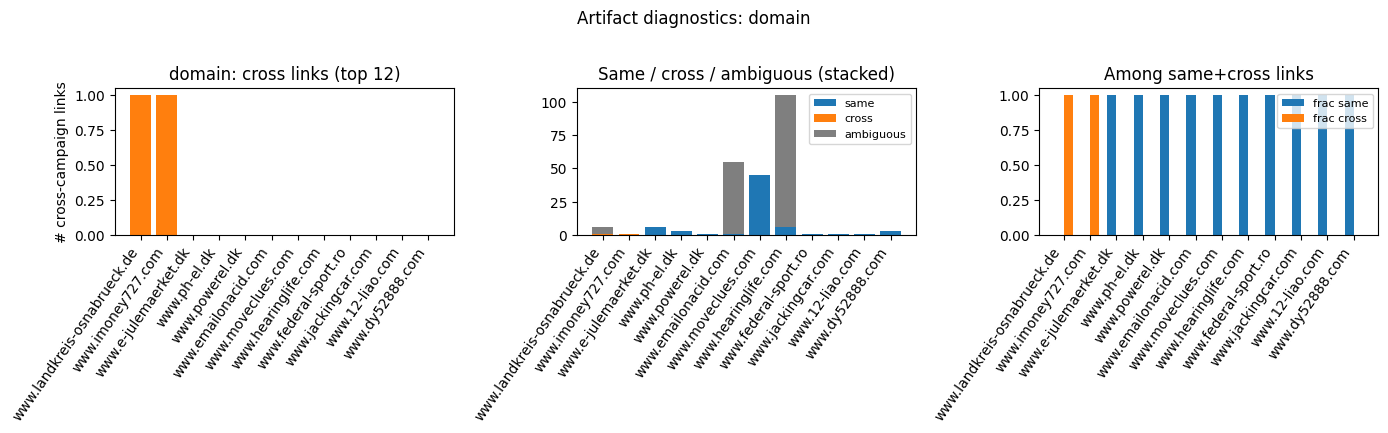

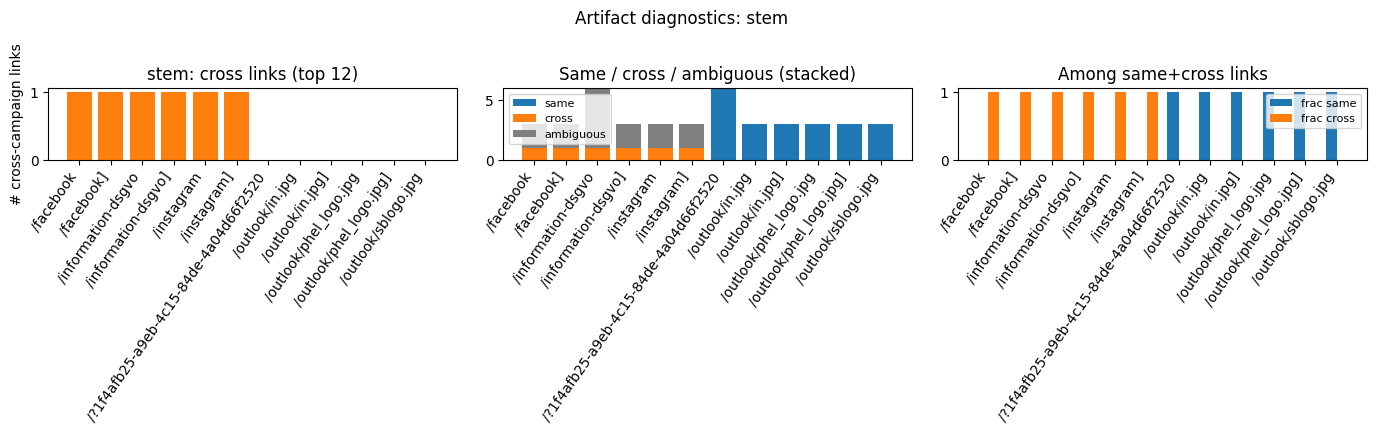

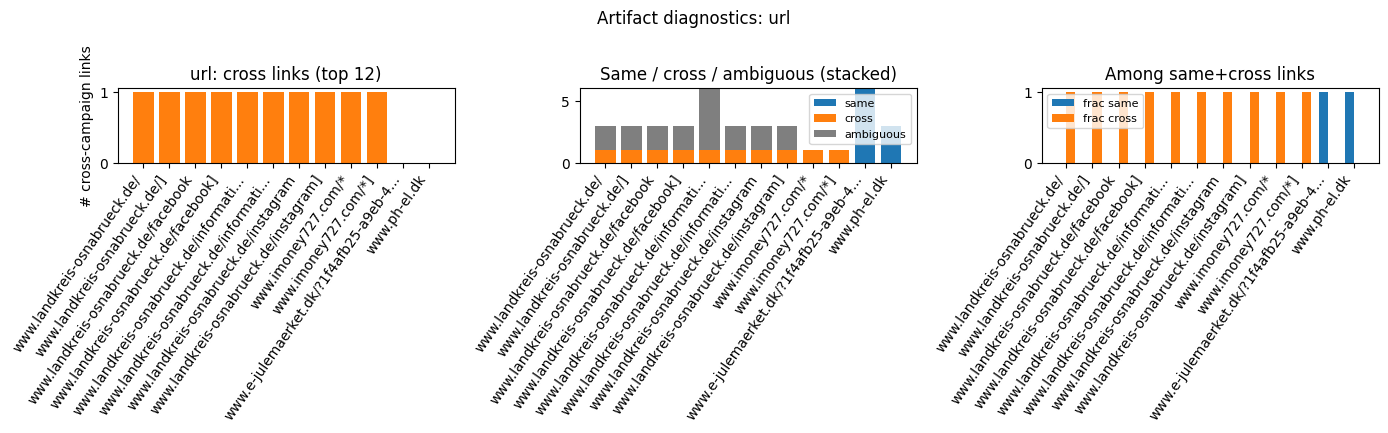

In [12]:
def _plot_top_artifact_triptych(summary: pd.DataFrame, atype: str, *, top_k: int = 12) -> None:
    sub = summary[summary["artifact_type"] == atype].copy()
    if sub.empty:
        display(Markdown(f"No summary rows for `{atype}` — skipped."))
        return
    sub = sub.sort_values("n_cross", ascending=False).head(int(top_k))
    labels = [plot_label_short(v, 40) for v in sub["artifact_value"]]
    x = np.arange(len(sub))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    axes[0].bar(x, sub["n_cross"], color=COLOR_CROSS)
    axes[0].set_title(f"{atype}: cross links (top {len(sub)})")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=55, ha="right")
    axes[0].set_ylabel("# cross-campaign links")
    axes[1].bar(x, sub["n_same"], label="same", color=COLOR_SAME)
    axes[1].bar(x, sub["n_cross"], bottom=sub["n_same"], label="cross", color=COLOR_CROSS)
    b_amb_base = sub["n_same"] + sub["n_cross"]
    axes[1].bar(x, sub["n_ambiguous"], bottom=b_amb_base, label="ambiguous", color=COLOR_AMBIG)
    axes[1].set_title("Same / cross / ambiguous (stacked)")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=55, ha="right")
    axes[1].legend(fontsize=8)
    w = 0.35
    axes[2].bar(x - w / 2, sub["frac_same_among_confident"].fillna(0), width=w, label="frac same", color=COLOR_SAME)
    axes[2].bar(x + w / 2, sub["frac_cross_among_confident"].fillna(0), width=w, label="frac cross", color=COLOR_CROSS)
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title("Among same+cross links")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels, rotation=55, ha="right")
    axes[2].legend(fontsize=8)
    fig.suptitle(f"Artifact diagnostics: {atype}", y=1.02)
    plt.tight_layout()
    plt.show()


for _atype in ("domain", "stem", "url"):
    if _atype not in set(artifact_summary_df["artifact_type"].unique()):
        display(Markdown(f"**Skip plots:** no `{_atype}` artifacts in summary."))
        continue
    _plot_top_artifact_triptych(artifact_summary_df, _atype, top_k=12)


### 9.3 Shard-frequency / genericness

**Shard frequency** counts how many semantic shards contain a value in their Step-2 node set (global breadth). High frequency plus many cross links is a hallmark of **generic** evidence (e.g. `w3.org`).


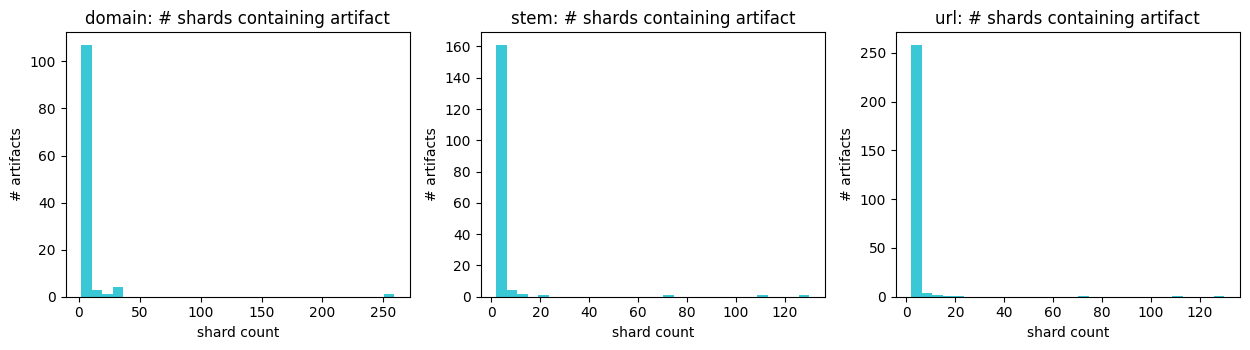

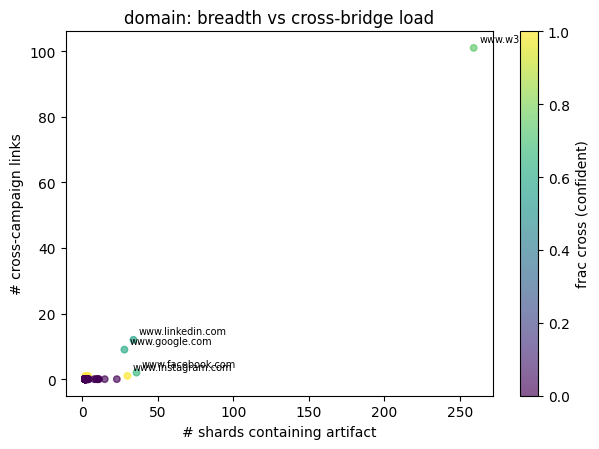

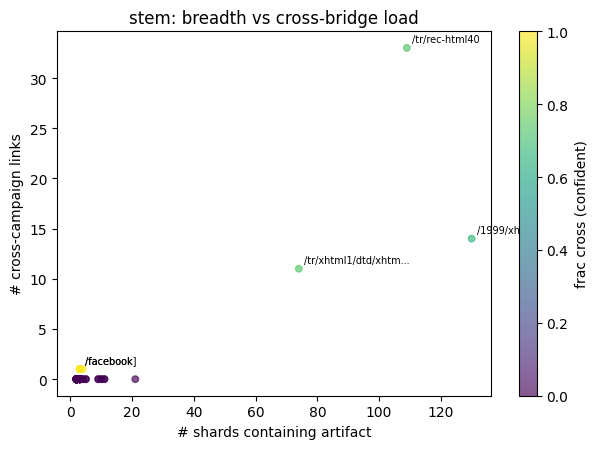

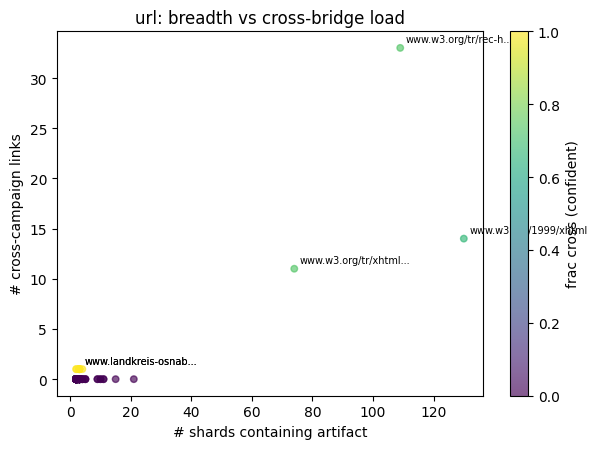

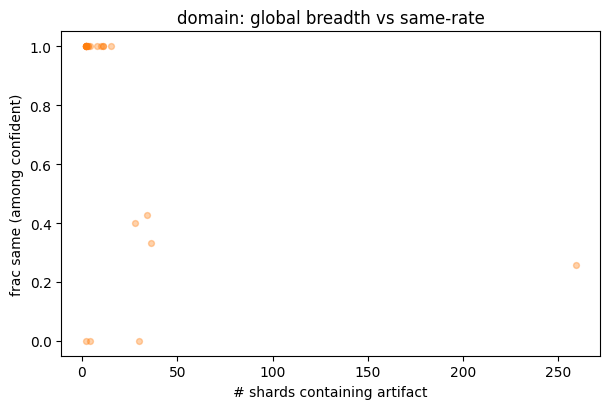

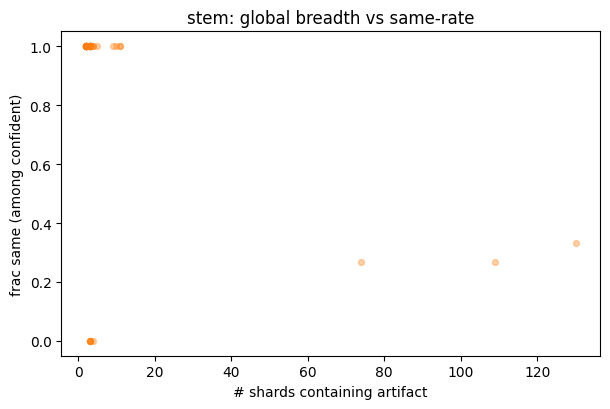

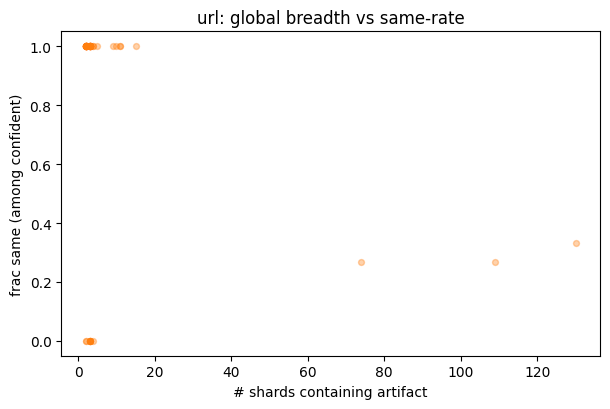

In [13]:
_types_for_plots = [t for t in ("domain", "stem", "url") if t in set(artifact_summary_df["artifact_type"].unique())]
if not _types_for_plots:
    display(Markdown("No domain/stem/url summaries — skip genericness plots."))
else:
    fig, axes = plt.subplots(1, len(_types_for_plots), figsize=(4.2 * len(_types_for_plots), 3.6))
    if len(_types_for_plots) == 1:
        axes = [axes]
    for ax, atype in zip(axes, _types_for_plots):
        s = artifact_summary_df[artifact_summary_df["artifact_type"] == atype]["n_shards_containing"].dropna()
        ax.hist(s.astype(int), bins=30, color="#17becf", alpha=0.85)
        ax.set_title(f"{atype}: # shards containing artifact")
        ax.set_xlabel("shard count")
        ax.set_ylabel("# artifacts")
    plt.tight_layout()
    plt.show()

    for atype in _types_for_plots:
        sub = artifact_summary_df[artifact_summary_df["artifact_type"] == atype].copy()
        if sub.empty:
            continue
        sub = sub.dropna(subset=["n_shards_containing", "n_cross"])
        fig, ax = plt.subplots(figsize=(6.2, 4.6))
        sc = ax.scatter(
            sub["n_shards_containing"].astype(float),
            sub["n_cross"].astype(float),
            c=sub["frac_cross_among_confident"].fillna(0),
            cmap="viridis",
            alpha=0.65,
            s=22,
        )
        plt.colorbar(sc, ax=ax, label="frac cross (confident)")
        top5 = sub.sort_values("n_cross", ascending=False).head(5)
        for _, r in top5.iterrows():
            ax.annotate(
                plot_label_short(r["artifact_value"], 22),
                (float(r["n_shards_containing"]), float(r["n_cross"])),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=7,
            )
        ax.set_xlabel("# shards containing artifact")
        ax.set_ylabel("# cross-campaign links")
        ax.set_title(f"{atype}: breadth vs cross-bridge load")
        plt.tight_layout()
        plt.show()

    for atype in _types_for_plots:
        sub = artifact_summary_df[artifact_summary_df["artifact_type"] == atype].copy()
        if sub.empty:
            continue
        sub = sub.dropna(subset=["n_shards_containing", "frac_same_among_confident"])
        fig, ax = plt.subplots(figsize=(6.2, 4.2))
        ax.scatter(
            sub["n_shards_containing"].astype(float),
            sub["frac_same_among_confident"].fillna(0),
            c=COLOR_CROSS,
            alpha=0.35,
            s=18,
        )
        ax.set_xlabel("# shards containing artifact")
        ax.set_ylabel("frac same (among confident)")
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"{atype}: global breadth vs same-rate")
        plt.tight_layout()
        plt.show()


### 9.4 Inspectable cross links by top artifacts

Small samples (cross-campaign only) for **domain / stem / URL**, focused on artifacts that rank high on cross-link count. Sorted **HS-LI first**, then semantic score.


In [14]:
_dom_idx = shard_summary.set_index("shard_id")


def _sample_cross_rows_for_top_artifacts(atype: str, *, top_artifacts: int = 8, max_rows: int = 14) -> pd.DataFrame:
    tops = (
        artifact_summary_df[artifact_summary_df["artifact_type"] == atype]
        .sort_values("n_cross", ascending=False)
        .head(top_artifacts)["artifact_value"]
        .tolist()
    )
    if not tops:
        return pd.DataFrame()
    sub = artifact_long_df[
        (artifact_long_df["artifact_type"] == atype)
        & (artifact_long_df["link_label"] == "cross")
        & (artifact_long_df["artifact_value"].isin(tops))
    ].copy()
    if sub.empty:
        return sub
    sub["src_dom"] = sub["shard_a"].map(lambda s: _dom_idx.at[str(s), "dominant_campaign"] if str(s) in _dom_idx.index else "")
    sub["src_frac"] = sub["shard_a"].map(
        lambda s: float(_dom_idx.at[str(s), "dominant_fraction"]) if str(s) in _dom_idx.index else float("nan")
    )
    sub["dst_dom"] = sub["shard_b"].map(lambda s: _dom_idx.at[str(s), "dominant_campaign"] if str(s) in _dom_idx.index else "")
    sub["dst_frac"] = sub["shard_b"].map(
        lambda s: float(_dom_idx.at[str(s), "dominant_fraction"]) if str(s) in _dom_idx.index else float("nan")
    )
    sub.sort_values(
        ["is_hsli", "semantic_aggregate"],
        ascending=[False, False],
        inplace=True,
    )
    keep = [
        "artifact_value",
        "shard_a",
        "shard_b",
        "link_label",
        "is_hsli",
        "semantic_aggregate",
        "infra_aggregate",
        "src_dom",
        "dst_dom",
        "src_frac",
        "dst_frac",
    ]
    return sub[[c for c in keep if c in sub.columns]].head(max_rows)


for _atype in ("domain", "stem", "url"):
    display(Markdown(f"#### Cross-edge samples — {_atype}"))
    _samp = _sample_cross_rows_for_top_artifacts(_atype)
    if _samp.empty:
        display(Markdown("_No rows (missing overlaps or no cross links for top artifacts)._"))
    else:
        with pd.option_context("display.max_colwidth", None):
            display(_samp)


#### Cross-edge samples — domain

,artifact_value,shard_a,shard_b,link_label,is_hsli,semantic_aggregate,infra_aggregate,src_dom,dst_dom,src_frac,dst_frac
2307,www.w3.org,shard_338,shard_334,cross,True,0.876984,0.565717,22.0,274.0,1.0,1.0
2286,www.w3.org,shard_338,shard_431,cross,True,0.866346,0.565717,22.0,46.0,1.0,1.0
10911,www.w3.org,shard_334,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnofCYgAAAA==,cross,True,0.856282,0.565717,274.0,22.0,1.0,1.0
10916,www.w3.org,shard_334,shard_337,cross,True,0.855229,0.565717,274.0,22.0,1.0,1.0
10917,www.w3.org,shard_334,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnofDJwAAAA==,cross,True,0.854612,0.565717,274.0,22.0,1.0,1.0
2554,www.w3.org,shard_338,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADvD8QNQAAAA==,cross,True,0.849386,0.565717,22.0,46.0,1.0,1.0
2462,www.w3.org,shard_338,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru9mAAAAA==,cross,True,0.846062,0.565717,22.0,46.0,1.0,1.0
10365,www.w3.org,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEMAADLFWG82DO5SZxCDBfRaVXNAAKWI9mrAAA=,shard_334,cross,True,0.844453,0.565717,46.0,274.0,1.0,1.0
2611,www.w3.org,shard_428,shard_334,cross,True,0.844072,0.565717,46.0,274.0,1.0,1.0
6725,www.w3.org,shard_431,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnofDJwAAAA==,cross,True,0.843616,0.565717,46.0,22.0,1.0,1.0


#### Cross-edge samples — stem

,artifact_value,shard_a,shard_b,link_label,is_hsli,semantic_aggregate,infra_aggregate,src_dom,dst_dom,src_frac,dst_frac
57547,/1999/xhtml,shard_431,shard_334,cross,False,0.870459,2.114982,46.0,274.0,1.0,1.0
57548,/tr/xhtml1/dtd/xhtml1-transitional.dtd,shard_431,shard_334,cross,False,0.870459,2.114982,46.0,274.0,1.0,1.0
59520,/1999/xhtml,shard_334,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru9mAAAAA==,cross,False,0.863836,2.114982,274.0,46.0,1.0,1.0
59521,/tr/xhtml1/dtd/xhtml1-transitional.dtd,shard_334,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru9mAAAAA==,cross,False,0.863836,2.114982,274.0,46.0,1.0,1.0
59591,/1999/xhtml,shard_334,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADvD8QNQAAAA==,cross,False,0.851144,2.071095,274.0,46.0,1.0,1.0
59513,/1999/xhtml,shard_334,shard_161,cross,False,0.849567,2.114982,274.0,11.0,1.0,1.0
59514,/tr/xhtml1/dtd/xhtml1-transitional.dtd,shard_334,shard_161,cross,False,0.849567,2.114982,274.0,11.0,1.0,1.0
57637,/1999/xhtml,shard_431,shard_161,cross,False,0.847414,2.114982,46.0,11.0,1.0,1.0
57638,/tr/xhtml1/dtd/xhtml1-transitional.dtd,shard_431,shard_161,cross,False,0.847414,2.114982,46.0,11.0,1.0,1.0
55400,/tr/rec-html40,shard_338,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEMAADLFWG82DO5SZxCDBfRaVXNAAKWI9mrAAA=,cross,False,0.846488,2.078248,22.0,46.0,1.0,1.0


#### Cross-edge samples — url

,artifact_value,shard_a,shard_b,link_label,is_hsli,semantic_aggregate,infra_aggregate,src_dom,dst_dom,src_frac,dst_frac
39595,www.w3.org/1999/xhtml,shard_431,shard_334,cross,False,0.870459,2.114982,46.0,274.0,1.0,1.0
39596,www.w3.org/tr/xhtml1/dtd/xhtml1-transitional.dtd,shard_431,shard_334,cross,False,0.870459,2.114982,46.0,274.0,1.0,1.0
41570,www.w3.org/1999/xhtml,shard_334,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru9mAAAAA==,cross,False,0.863836,2.114982,274.0,46.0,1.0,1.0
41571,www.w3.org/tr/xhtml1/dtd/xhtml1-transitional.dtd,shard_334,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru9mAAAAA==,cross,False,0.863836,2.114982,274.0,46.0,1.0,1.0
41641,www.w3.org/1999/xhtml,shard_334,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADvD8QNQAAAA==,cross,False,0.851144,2.071095,274.0,46.0,1.0,1.0
41563,www.w3.org/1999/xhtml,shard_334,shard_161,cross,False,0.849567,2.114982,274.0,11.0,1.0,1.0
41564,www.w3.org/tr/xhtml1/dtd/xhtml1-transitional.dtd,shard_334,shard_161,cross,False,0.849567,2.114982,274.0,11.0,1.0,1.0
39685,www.w3.org/1999/xhtml,shard_431,shard_161,cross,False,0.847414,2.114982,46.0,11.0,1.0,1.0
39686,www.w3.org/tr/xhtml1/dtd/xhtml1-transitional.dtd,shard_431,shard_161,cross,False,0.847414,2.114982,46.0,11.0,1.0,1.0
37434,www.w3.org/tr/rec-html40,shard_338,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBlYjJjN2FkZDViOQBGAAAAAABfotMHHH7tSZosKVtSM-EWBwDLFWG82DO5SZxCDBfRaVXNAAAAAAEMAADLFWG82DO5SZxCDBfRaVXNAAKWI9mrAAA=,cross,False,0.846488,2.078248,22.0,46.0,1.0,1.0


### 9.5 Heuristic filtering / downweight candidates

Not automatic filtering — a ranked shortlist combining **high shard frequency**, **cross-heavy** confident links, and **HS-LI cross** exposure. Use for follow-up allowlists, IDF tuning, or bucket design.


,artifact_type,artifact_value,n_cross,n_same,frac_cross_among_confident,n_shards_containing,n_hsli_cross,high_shard_freq_heuristic
0,domain,www.w3.org,101.0,35.0,0.742647,259,19.0,True
1,url,www.w3.org/tr/rec-html40,33.0,12.0,0.733333,109,0.0,True
2,stem,/tr/rec-html40,33.0,12.0,0.733333,109,0.0,True
3,stem,/tr/xhtml1/dtd/xhtml1-transitional.dtd,11.0,4.0,0.733333,74,0.0,True
4,url,www.w3.org/tr/xhtml1/dtd/xhtml1-transitional.dtd,11.0,4.0,0.733333,74,0.0,True
5,url,www.w3.org/1999/xhtml,14.0,7.0,0.666667,130,0.0,True
6,stem,/1999/xhtml,14.0,7.0,0.666667,130,0.0,True
7,domain,www.linkedin.com,12.0,9.0,0.571429,34,0.0,True
8,domain,www.google.com,9.0,6.0,0.600000,28,0.0,True
9,sender,bslservice@bluestarindia.com,0.0,231.0,0.000000,22,0.0,True


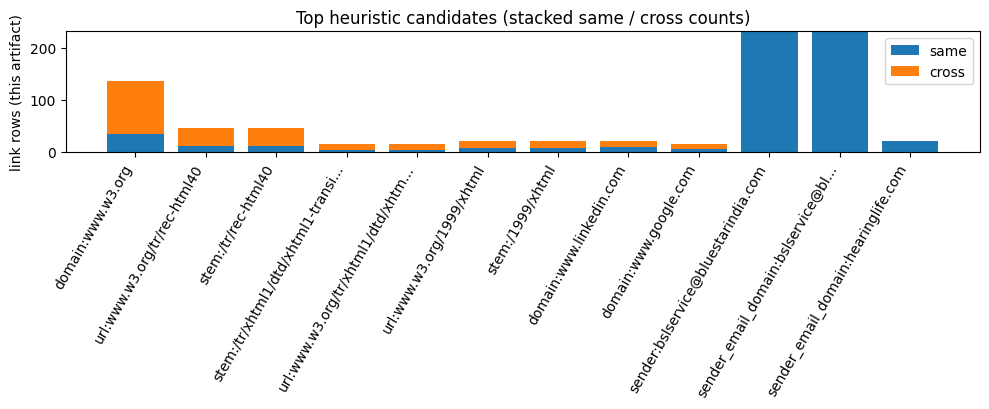

In [15]:
artifact_candidates = artifact_filtering_candidates(artifact_summary_df, min_conf_links=5)
if artifact_candidates.empty:
    display(Markdown("No candidates passed minimum support — skip."))
else:
    _show = artifact_candidates[
        [
            c
            for c in (
                "artifact_type",
                "artifact_value",
                "n_cross",
                "n_same",
                "frac_cross_among_confident",
                "n_shards_containing",
                "n_hsli_cross",
                "high_shard_freq_heuristic",
            )
            if c in artifact_candidates.columns
        ]
    ].head(18)
    with pd.option_context("display.max_colwidth", 80):
        display(_show)
    _top = artifact_candidates.head(12).copy()
    _top["plot_label"] = _top.apply(
        lambda r: plot_label_short(f"{r['artifact_type']}:{r['artifact_value']}", 36),
        axis=1,
    )
    fig, ax = plt.subplots(figsize=(10, 4.2))
    x = np.arange(len(_top))
    ax.bar(x, _top["n_same"], color=COLOR_SAME, label="same")
    ax.bar(x, _top["n_cross"], bottom=_top["n_same"], color=COLOR_CROSS, label="cross")
    ax.set_xticks(x)
    ax.set_xticklabels(_top["plot_label"], rotation=60, ha="right")
    ax.set_ylabel("link rows (this artifact)")
    ax.set_title("Top heuristic candidates (stacked same / cross counts)")
    ax.legend()
    plt.tight_layout()
    plt.show()


### Interpretation

Artifacts that induce **many cross links** may be **generic**, **benign**, or **poorly normalized** — not necessarily “wrong” to exist in email, but risky as **hard evidence** for merging shards.

Some high-frequency values still appear on **same-campaign** links; **breadth alone does not mean** an artifact should be dropped. These plots narrow **where to spend manual review** and inform later steps: benign-domain filtering, rarity / IDF shaping, overlap gating, and hard-negative construction for contrastive or scoring models.


## 10. Conclusions (for unsupervised bucket design)

Fill in after running on your artifacts:

- **Most common evidence on same links:** (see §4 grouped bars and §5 channel counts.)
- **Most common on cross links:** same plots — often infra-light + semantic-only patterns.
- **Most distinguishing channels:** §4 difference chart (positive ⇒ more common on same).
- **HS-LI risks:** §4 HS-LI panel — which channels still appear on cross edges without infra?
- **Cross-edge spot checks:** §8 — which shared tokens look generic or suspicious on cross links?
- **Concrete overlap drivers:** §9 — which exact domains / URLs / stems induce the most cross links, and which look globally generic vs campaign-bearing?
- **Subject vs body:** §6 — if subject-only links skew **cross-heavy** vs body-only, treat subject similarity as higher false-bridge prior unless corroborated.
- **Design takeaway:** favor buckets that require **multi-channel corroboration** for high-semantic / low-infra proposals; down-weight subject-only edges if §6 shows higher cross rate.


## Export

CSV artifacts land in `OUT_DIR`. A short markdown summary is written for quick sharing.


In [16]:
extra = [
    f"Edge taxonomy min dominant fraction={MIN_DOMINANT_FRAC_FOR_EDGE_LABEL}; oracle merge purity={ORACLE_PURITY_THRESHOLD}.",
    "Oracle A: merge pure same-campaign shards ignoring graph; Oracle B: merge only along Step-2 edges.",
    "Main focus: edge_analysis_df + shard-link diagnostic plots (not model evaluation).",
]

write_oracle_headroom_summary_md(
    OUT_DIR / "semantic_shard_oracle_headroom_summary.md",
    pure_shard_metrics=pure_metrics,
    oracle_a=oracle_a,
    oracle_b=oracle_b,
    purity_global=purity_global,
    taxonomy_counts=edges_tax["edge_taxonomy"].value_counts(),
    extra_bullets=extra,
)
print("Wrote", OUT_DIR / "semantic_shard_oracle_headroom_summary.md")


Wrote C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_oracle_headroom\semantic_shard_oracle_headroom_summary.md
